In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
(X_train,y_train),(X_test,y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
X_train.shape

(50000, 32, 32, 3)

In [4]:
X_test.shape

(10000, 32, 32, 3)

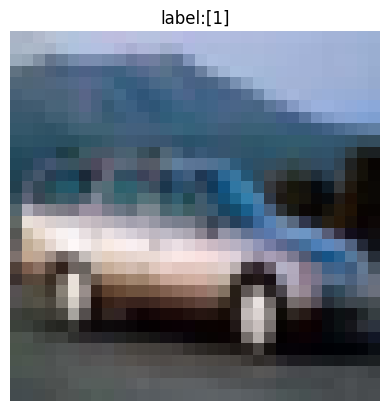

In [5]:
plt.imshow(X_train[4])
plt.title(f'label:{y_train[4]}')
plt.axis('off')
plt.show()

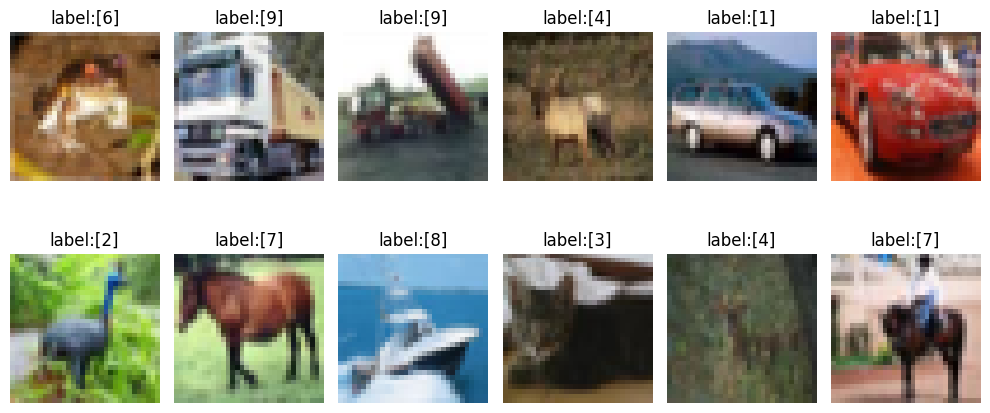

In [6]:
plt.figure(figsize=(10,5))

for i in range(12):
    plt.subplot(2,6 ,i+1)
    plt.imshow(X_train[i])
    plt.title(f'label:{y_train[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
X_train = X_train/255.0
X_test = X_test/255.0

In [13]:
y_train.shape

(50000, 1)

In [8]:
y_train=y_train.flatten()
y_test=y_test.flatten()

In [16]:
y_train

array([6, 9, 9, ..., 9, 1, 1], dtype=uint8)

In [9]:
cnn_model=models.Sequential()

In [10]:
cnn_model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
cnn_model.add(layers.BatchNormalization())
cnn_model.add(layers.MaxPooling2D((2,2)))

In [12]:
cnn_model.add(layers.Conv2D(64,(3,3),activation='relu'))
cnn_model.add(layers.BatchNormalization())
cnn_model.add(layers.MaxPooling2D((2,2)))

In [13]:
cnn_model.add(layers.Conv2D(128,(3,3),activation='relu'))
cnn_model.add(layers.BatchNormalization())

In [14]:
cnn_model.add(layers.Flatten())
cnn_model.add(layers.Dense(128,activation='relu'))
cnn_model.add(layers.Dropout(0.5))
cnn_model.add(layers.Dense(10,activation='softmax'))

In [25]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
cnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [16]:
history=cnn_model.fit(X_train,y_train,epochs=10,batch_size=64,validation_split=0.2,verbose=2)

Epoch 1/10
625/625 - 80s - 128ms/step - accuracy: 0.4562 - loss: 1.6289 - val_accuracy: 0.5423 - val_loss: 1.3058
Epoch 2/10
625/625 - 78s - 125ms/step - accuracy: 0.5919 - loss: 1.1671 - val_accuracy: 0.5629 - val_loss: 1.2412
Epoch 3/10
625/625 - 81s - 130ms/step - accuracy: 0.6528 - loss: 0.9921 - val_accuracy: 0.6044 - val_loss: 1.1281
Epoch 4/10
625/625 - 81s - 130ms/step - accuracy: 0.6932 - loss: 0.8762 - val_accuracy: 0.6386 - val_loss: 1.0420
Epoch 5/10
625/625 - 83s - 132ms/step - accuracy: 0.7238 - loss: 0.7884 - val_accuracy: 0.7027 - val_loss: 0.8457
Epoch 6/10
625/625 - 72s - 116ms/step - accuracy: 0.7474 - loss: 0.7149 - val_accuracy: 0.6682 - val_loss: 0.9501
Epoch 7/10
625/625 - 81s - 129ms/step - accuracy: 0.7721 - loss: 0.6449 - val_accuracy: 0.7293 - val_loss: 0.8184
Epoch 8/10
625/625 - 84s - 134ms/step - accuracy: 0.7915 - loss: 0.5908 - val_accuracy: 0.6953 - val_loss: 0.9921
Epoch 9/10
625/625 - 74s - 118ms/step - accuracy: 0.8102 - loss: 0.5345 - val_accuracy: 

In [17]:
test_loss, test_accuracy=cnn_model.evaluate(X_test,y_test,verbose=2)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

313/313 - 5s - 16ms/step - accuracy: 0.7321 - loss: 0.8981
Test Loss: 0.8981
Test Accuracy: 0.7321


In [18]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


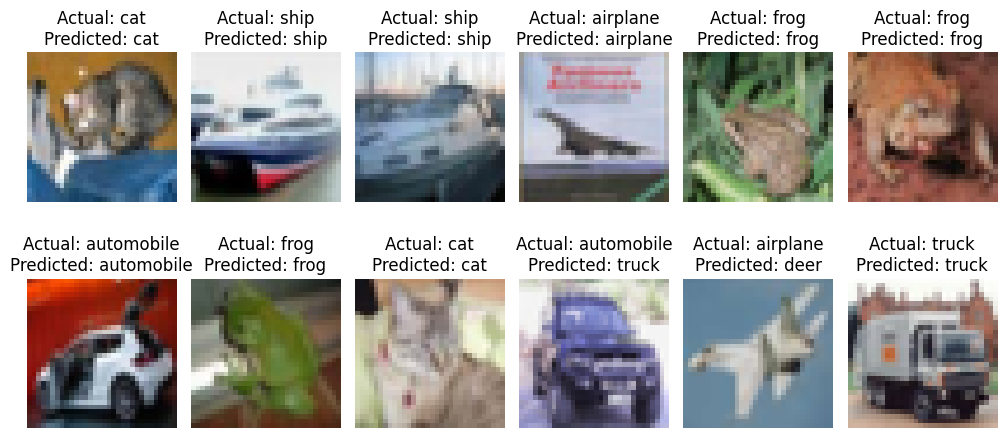

In [19]:
sample_images = X_test[:12]
sample_labels = y_test[:12]
predictions = cnn_model.predict(sample_images)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 5))
for i in range(12):
    plt.subplot(2, 6, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"Actual: {class_names[sample_labels[i]]}\nPredicted: {class_names[predicted_labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

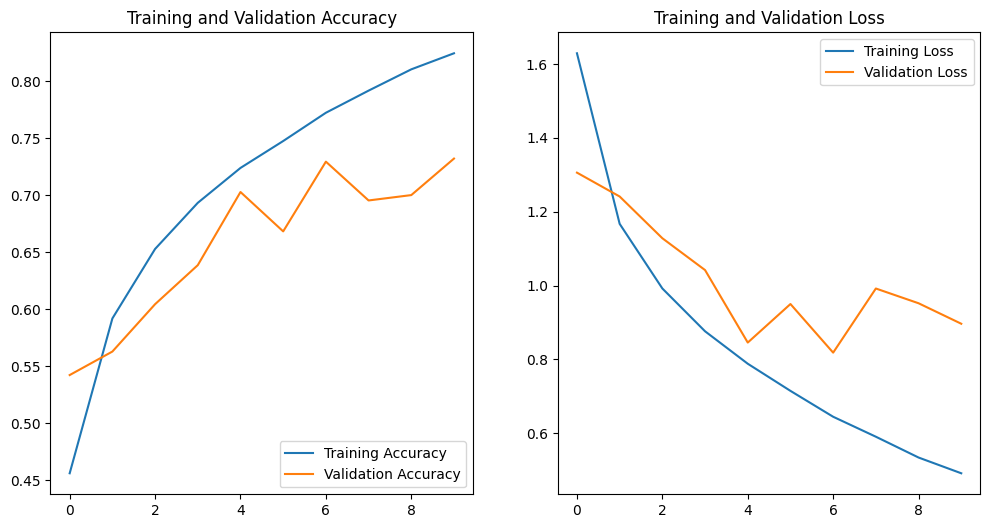

In [20]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


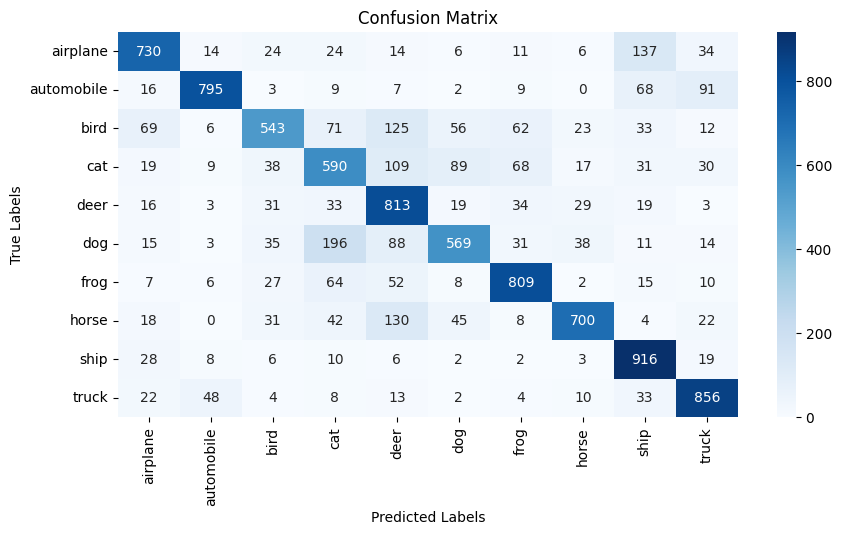

In [22]:
y_pred=np.argmax(cnn_model.predict(X_test),axis=1)
conf_metrix=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,5))
sns.heatmap(conf_metrix,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [23]:
report=classification_report(y_test,y_pred,target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.78      0.73      0.75      1000
  automobile       0.89      0.80      0.84      1000
        bird       0.73      0.54      0.62      1000
         cat       0.56      0.59      0.58      1000
        deer       0.60      0.81      0.69      1000
         dog       0.71      0.57      0.63      1000
        frog       0.78      0.81      0.79      1000
       horse       0.85      0.70      0.77      1000
        ship       0.72      0.92      0.81      1000
       truck       0.78      0.86      0.82      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000



In [24]:
cnn_model.save('cifar10_model.h5')
print('Model saved successfully.')

Model saved successfully.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


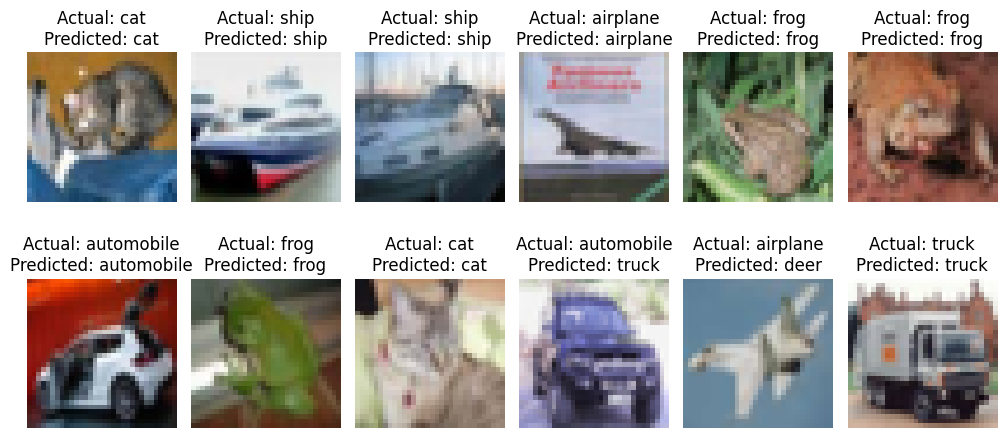

In [25]:
load_model=tf.keras.models.load_model('cifar10_model.h5')
sample_images = X_test[:12]
sample_labels = y_test[:12]
predictions = np.argmax(load_model.predict(sample_images), axis=1)
plt.figure(figsize=(10,5))
for i in range(12):
    plt.subplot(2,6,i+1)
    plt.imshow(sample_images[i])
    plt.title(f"Actual: {class_names[sample_labels[i]]}\nPredicted: {class_names[predictions[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()